# After-Sales Service Process Mining
### Mining a real service-ticket event log to find where tickets bounce, stall, and reopen

**What this is.** A process-mining analysis of a real, public IT service-desk event log
(BPI Challenge 2013 — Volvo IT incident management, 7,554 tickets / 65,533 events), used as a
stand-in for an **appliance after-sales service process**. The event structure: ticket
lifecycle, reassignments, reopens, SLA waits: is identical to what an HVAC/appliance service
network generates (complaint → assigned → technician → parts → resolved → reopened? → closed).

**Translation layer** (stated once, used throughout):

| IT service-desk reality | Appliance after-sales analog |
|---|---|
| `org:group` handover | Ticket reassigned / wrong team / repeat technician dispatch |
| `Wait - User` / `Wait - Vendor` | Waiting on the customer / waiting on spare parts |
| Resolved → reopened | Repeat complaint, not first-time-fixed |
| Throughput time | Resolution time vs SLA |

**The five questions** (each = a field-service KPI): (1) happy-path conformance, (2) first-time-fix /
reopen rate, (3) the biggest ping-pong loop, (4) the bottleneck, (5) does reassignment drive
resolution time?

In [ ]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import pm4py
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import Image, display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 110

# Locate the repo root.
BASE = next((c for c in (Path.cwd(), Path.cwd().parent)
             if (c / "data" / "BPI_Challenge_2013_incidents.xes.gz").exists()), Path.cwd())
FIG = BASE / "figures"; FIG.mkdir(exist_ok=True)
gv = r"C:\Program Files\Graphviz\bin"
if os.path.isdir(gv) and gv not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + gv

CASE, STATUS, SUB, GROUP, TS = ("case:concept:name", "concept:name",
                                "lifecycle:transition", "org:group", "time:timestamp")
print("repo root:", BASE)

repo root: c:\Projects\Panda Projects\Post Sales Process Mining


## 1. Load the log and understand the data

A key schema detail: `concept:name` holds only the 4 top-level **statuses**
(`Accepted`/`Completed`/`Queued`/`Unmatched`); the real **sub-status** detail lives in
`lifecycle:transition`. So the meaningful activity is the **composite** of the two,
e.g. `Accepted / In Progress`, `Completed / Resolved`, `Queued / Awaiting Assignment`.

In [2]:
df = pm4py.read_xes(str(BASE / "data" / "BPI_Challenge_2013_incidents.xes.gz"))
df = df.reset_index(drop=True)
df["evt_order"] = df.index                       # stable tie-breaker for equal timestamps
df["activity"] = df[STATUS].astype(str) + " / " + df[SUB].astype(str)
df = df.sort_values([CASE, TS, "evt_order"]).reset_index(drop=True)

print(f"events : {len(df):,}")
print(f"cases  : {df[CASE].nunique():,}")
print(f"range  : {df[TS].min():%Y-%m-%d} → {df[TS].max():%Y-%m-%d}")
print(f"teams  : {df[GROUP].nunique()} distinct org:group (0 nulls)")
print("\nComposite activities (13):")
df["activity"].value_counts()

parsing log, completed traces ::   0%|          | 0/7554 [00:00<?, ?it/s]

events : 65,533
cases  : 7,554
range  : 2010-03-31 → 2012-05-23
teams  : 649 distinct org:group (0 nulls)

Composite activities (13):


activity
Accepted / In Progress              30239
Queued / Awaiting Assignment        11544
Completed / Resolved                 6115
Completed / Closed                   5716
Accepted / Wait - User               4217
Accepted / Assigned                  3221
Completed / In Call                  2035
Accepted / Wait                      1533
Accepted / Wait - Implementation      493
Accepted / Wait - Vendor              313
Accepted / Wait - Customer            101
Unmatched / Unmatched                   5
Completed / Cancelled                   1
Name: count, dtype: int64

In [3]:
# Per-case ordered views, reused by every question below.
g = df.groupby(CASE, sort=False)
seq_status = g[STATUS].apply(list)
seq_sub    = g[SUB].apply(list)
seq_act    = g["activity"].apply(list)
dur_days   = (g[TS].max() - g[TS].min()).dt.total_seconds() / 86400.0
n_cases    = len(seq_status)

### Discovered process map
The directly-follows map of the raw statuses already exposes the three pathologies this
project is about: a huge **self-loop on `Accepted`** (rework), **`Completed` → `Accepted`**
(reopens), and **`Accepted` ↔ `Queued`** (ping-pong into/out of the assignment queue).

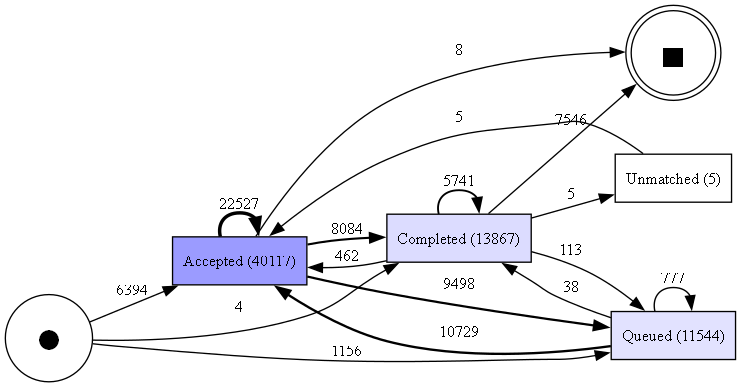

In [4]:
dfg, start, end = pm4py.discover_dfg(df)
map_path = FIG / "01_first_process_map_dfg.png"
pm4py.save_vis_dfg(dfg, start, end, str(map_path))
display(Image(filename=str(map_path)))

## Q1: Happy-path conformance
How many tickets follow the clean path (`In Progress → Resolved → Closed`) vs take a detour?

In [5]:
IDEAL = ("Accepted / In Progress", "Completed / Resolved", "Completed / Closed")
variants = seq_act.apply(tuple).value_counts()
exact = int(variants.get(IDEAL, 0))
print(f"Exact-match to ideal path : {exact:,} / {n_cases:,} = {exact/n_cases:.1%}")
print(f"Distinct variants (paths) : {variants.size:,}")
print("\nTop 5 real variants:")
for v, c in variants.head(5).items():
    print(f"  {c:>4} ({c/n_cases:4.1%})  {' → '.join(v)}")

Exact-match to ideal path : 0 / 7,554 = 0.0%
Distinct variants (paths) : 2,278

Top 5 real variants:
  1749 (23.2%)  Accepted / In Progress → Accepted / In Progress → Completed / In Call
   524 (6.9%)  Accepted / In Progress → Accepted / In Progress → Completed / Resolved → Completed / Closed
   352 (4.7%)  Accepted / In Progress → Accepted / In Progress → Queued / Awaiting Assignment → Accepted / In Progress → Completed / Resolved → Completed / Closed
   300 (4.0%)  Queued / Awaiting Assignment → Accepted / In Progress → Completed / Resolved → Completed / Closed
   203 (2.7%)  Accepted / In Progress → Accepted / In Progress → Queued / Awaiting Assignment → Accepted / In Progress → Accepted / Wait - User → Completed / Resolved → Completed / Closed


**Exact conformance is 0%**: expected, and itself informative. Real tickets always repeat
`In Progress` or pass through the queue first, so a literal happy path never occurs across
**2,278 distinct paths**. The honest conformance metric is *soft*: does a ticket end
completed and never bounce back? But "completed" hides a trap, handled next.

In [ ]:
# Observation: status `Completed` also covers `In Call` (agent on the phone = mid-work, NOT a fix).
# Genuine resolution = sub-status in {Resolved, Closed}. Measure how many tickets never get
# a formal resolution stamp.
RESOLVED = {"Resolved", "Closed"}
ever_resolved = seq_sub.apply(lambda subs: any(s in RESOLVED for s in subs))
never_resolved = ~ever_resolved
print(f"Tickets that NEVER reach Resolved/Closed: "
      f"{int(never_resolved.sum()):,} / {n_cases:,} = {never_resolved.mean():.1%}")
print("(They end at 'In Call', a 'Wait' state, or in the queue — closed without formal\n"
      " resolution: a process-compliance / data-hygiene gap, or genuine abandonment.)")

Tickets that NEVER reach Resolved/Closed: 1,891 / 7,554 = 25.0%
(They end at 'In Call', a 'Wait' state, or in the queue — closed without formal
 resolution: a process-compliance / data-hygiene gap, or genuine abandonment.)


> **Finding A: 1 in 4 tickets is never formally resolved.** 25.0% reach no `Resolved`/`Closed`
> stamp. In an appliance context that's a service call logged as handled-on-the-phone but never
> closed in the system — invisible work that corrupts every downstream SLA and first-time-fix metric.

## Q2: First-time-fix / reopen rate
A **reopen** = a ticket reaches a genuine resolution (`Resolved`/`Closed`) and then returns to
active work. The denominator is *resolved* tickets only, you can't reopen what was never resolved.

In [7]:
ACTIVE = {"In Progress", "Awaiting Assignment", "Assigned", "In Call", "Wait - User",
          "Wait", "Wait - Implementation", "Wait - Vendor", "Wait - Customer"}

def reopened(subs):
    seen = False
    for s in subs:
        if s in RESOLVED: seen = True
        elif seen and s in ACTIVE: return True
    return False

reopen_flag = seq_sub.apply(reopened)
n_resolved = int(ever_resolved.sum())
print(f"Reopened tickets            : {int(reopen_flag.sum()):,}")
print(f"Resolved tickets (denom)    : {n_resolved:,}")
print(f"Reopen rate (of resolved)   : {reopen_flag.sum()/n_resolved:.1%}")
print(f"First-time-fix rate         : {1 - reopen_flag.sum()/n_resolved:.1%}")

Reopened tickets            : 390
Resolved tickets (denom)    : 5,663
Reopen rate (of resolved)   : 6.9%
First-time-fix rate         : 93.1%


> **Finding B: 6.9% of resolved tickets were reopened** (first-time-fix ≈ 93%). Each reopen in
> field service is a second truck-roll: more labour, more parts, lower CSAT, and a customer less
> likely to renew the AMC.

### Throughput-time distribution
Resolution time is heavily right-skewed (parked tickets sit for months), so we report the
**median**, not the mean, and plot on a log scale.

median 7.5 d | mean 12.1 d (1.6x median) | p90 23 | p95 36 | p99 117 | max 771 d


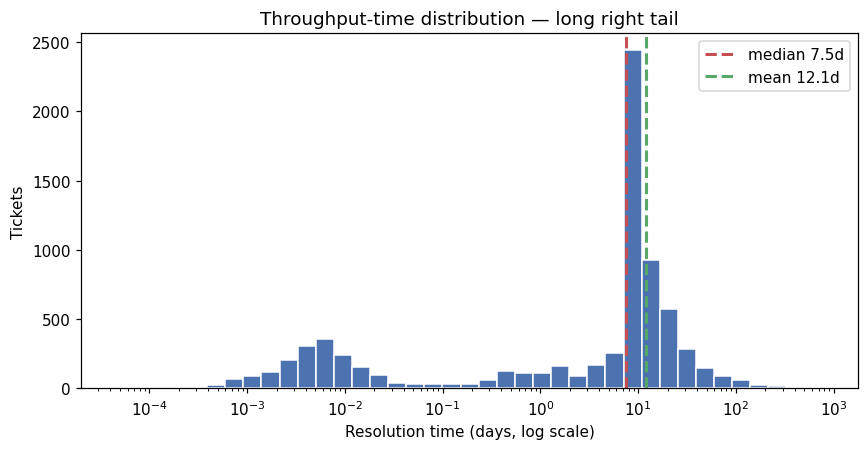

In [8]:
q = dur_days.quantile([0.5, 0.9, 0.95, 0.99])
print(f"median {dur_days.median():.1f} d | mean {dur_days.mean():.1f} d "
      f"({dur_days.mean()/dur_days.median():.1f}x median) | "
      f"p90 {q[0.9]:.0f} | p95 {q[0.95]:.0f} | p99 {q[0.99]:.0f} | max {dur_days.max():.0f} d")

pos = dur_days[dur_days > 0]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(pos, bins=np.logspace(np.log10(pos.min()), np.log10(pos.max()), 40),
        color="#4C72B0", edgecolor="white")
ax.set_xscale("log")
ax.axvline(dur_days.median(), color="#C44E52", ls="--", lw=2, label=f"median {dur_days.median():.1f}d")
ax.axvline(dur_days.mean(), color="#55A868", ls="--", lw=2, label=f"mean {dur_days.mean():.1f}d")
ax.set(xlabel="Resolution time (days, log scale)", ylabel="Tickets",
       title="Throughput-time distribution — long right tail")
ax.legend(); fig.tight_layout()
fig.savefig(FIG / "02_throughput_histogram.png", dpi=130); plt.show()

## Q3: The biggest ping-pong loop
**Reassignment = a change in `org:group`** between consecutive events. Ping-pong = `A → B → A`,
a ticket handed away and handed straight back — motion with no progress.

Reassignments/case: mean 1.25, median 1, max 31
Tickets with ≥1 ping-pong bounce: 1,177 (15.6%)
Worst loop: D8 ↔ V37 2nd (84 bounce-backs)


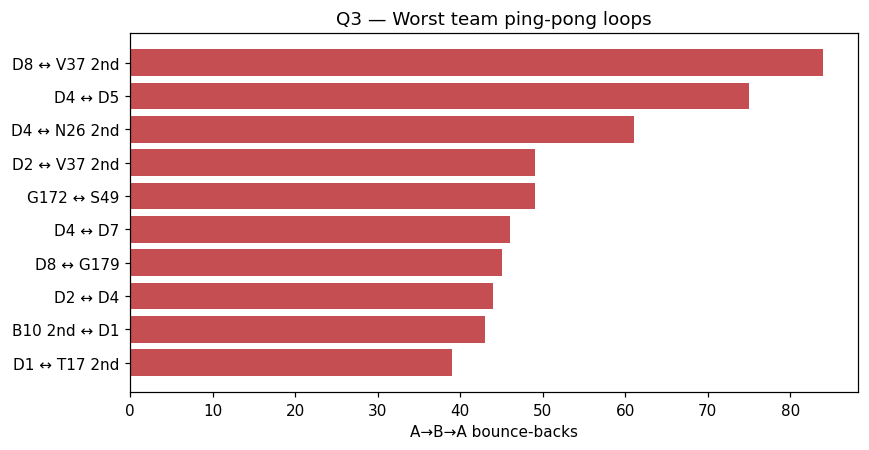

In [9]:
def collapse(seq):
    out = []
    for x in seq:
        if pd.isna(x): continue
        if not out or out[-1] != x: out.append(x)
    return out

team_path = g[GROUP].apply(lambda s: collapse(list(s)))
n_reassign = team_path.apply(lambda p: max(len(p) - 1, 0))

pingpong = Counter()
for p in team_path:
    for i in range(len(p) - 2):
        if p[i] == p[i + 2] and p[i] != p[i + 1]:
            pingpong[frozenset((p[i], p[i + 1]))] += 1

pp = sorted(pingpong.items(), key=lambda kv: kv[1], reverse=True)
n_pp_cases = sum(1 for p in team_path
                 if any(p[i]==p[i+2] and p[i]!=p[i+1] for i in range(len(p)-2)))
print(f"Reassignments/case: mean {n_reassign.mean():.2f}, median {n_reassign.median():.0f}, max {n_reassign.max()}")
print(f"Tickets with ≥1 ping-pong bounce: {n_pp_cases:,} ({n_pp_cases/n_cases:.1%})")
wa, wb = sorted(pp[0][0])
print(f"Worst loop: {wa} ↔ {wb} ({pp[0][1]} bounce-backs)")

labels = [f"{sorted(p)[0]} ↔ {sorted(p)[1]}" for p, _ in pp[:10]]
vals = [c for _, c in pp[:10]]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(labels[::-1], vals[::-1], color="#C44E52")
ax.set(xlabel="A→B→A bounce-backs", title="Q3 — Worst team ping-pong loops")
fig.tight_layout(); fig.savefig(FIG / "03_pingpong.png", dpi=130); plt.show()

> **15.6% of tickets ping-pong between teams**; the worst pair (`D8 ↔ V37 2nd`) bounced 84 times.
> In after-sales this is the call-center↔field↔spare-parts hand-off where each bounce burns days.

## Q4: The bottleneck (longest wait)
Sojourn time = how long a ticket sits in a state before the next event. **Caveat:** the raw
longest sojourn is `Completed / Resolved` (~7 days), but that's the **administrative
Resolved→Closed cooldown** (the system waits before auto-closing), *not* an operational
bottleneck — so we exclude the terminal/admin states and rank genuine operational waits.

In [10]:
df["sojourn_h"] = (g[TS].shift(-1) - df[TS]).dt.total_seconds() / 3600.0
soj = df.dropna(subset=["sojourn_h"])
agg = soj.groupby("activity")["sojourn_h"].agg(median_h="median", n="count")
agg["total_days"] = soj.groupby("activity")["sojourn_h"].sum() / 24.0
ADMIN = {"Completed / Resolved", "Completed / Closed", "Completed / In Call", "Unmatched / Unmatched"}
oper = agg[~agg.index.isin(ADMIN)].sort_values("median_h", ascending=False)
print("Operational waits (admin cooldown excluded):")
print(oper[["median_h", "total_days", "n"]].round(1).to_string())
print(f"\nLongest single wait : {oper.index[0]} ({oper.iloc[0]['median_h']:.0f} h median)")
print(f"Most total time lost: {oper['total_days'].idxmax()} "
      f"({oper['total_days'].max():.0f} cumulative days)")

Operational waits (admin cooldown excluded):
                                  median_h  total_days      n
activity                                                     
Accepted / Wait - Customer            54.4       485.9    101
Accepted / Wait - Vendor              28.2      1716.9    313
Accepted / Wait - User                26.4     19311.9   4214
Accepted / Wait - Implementation      26.0      2664.6    491
Accepted / Wait                        3.4      6260.7   1533
Accepted / Assigned                    1.4      4872.2   3220
Queued / Awaiting Assignment           0.6     12585.0  11544
Accepted / In Progress                 0.0     13396.8  30237

Longest single wait : Accepted / Wait - Customer (54 h median)
Most total time lost: Accepted / Wait - User (19312 cumulative days)


> **Waiting on the customer/user is the dominant operational delay**: `Wait - User` alone burns
> ~19,300 cumulative days; `Wait - Customer` is the longest single wait (~2.3 d). **Queue
> assignment is *not* the bottleneck** (median 0.6 h). After-sales analog: waiting on customer
> access/information and on **spare parts** (`Wait - Vendor`), not on dispatching.

## Q5: The driver: does reassignment predict resolution time?
The diagnostic. If reassignment count tracks resolution time — *and survives controlling for
ticket severity* — then the slow tail is a routing problem, not just hard tickets.

Spearman r = 0.557 (p=0e+00)

        median_days     n
bucket                   
0              0.29  3734
1              8.43  1764
2              9.98   973
3+            13.90  1083


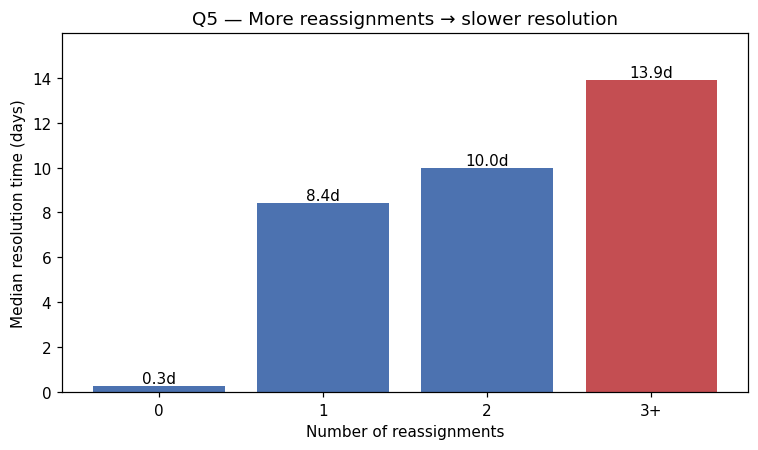

In [11]:
drv = pd.DataFrame({"reassign": n_reassign, "days": dur_days}).dropna()
drv = drv[drv["days"] >= 0]
spear = stats.spearmanr(drv["reassign"], drv["days"])
drv["bucket"] = pd.cut(drv["reassign"], [-1, 0, 1, 2, 100], labels=["0", "1", "2", "3+"])
bk = drv.groupby("bucket", observed=True)["days"].agg(median_days="median", n="count")
print(f"Spearman r = {spear.statistic:.3f} (p={spear.pvalue:.0e})\n")
print(bk.round(2).to_string())

fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(bk.index.astype(str), bk["median_days"],
              color=["#4C72B0", "#4C72B0", "#4C72B0", "#C44E52"])
for b, v in zip(bars, bk["median_days"]):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:.1f}d", ha="center", va="bottom")
ax.set(xlabel="Number of reassignments", ylabel="Median resolution time (days)",
       title="Q5 — More reassignments → slower resolution")
ax.margins(y=0.15); fig.tight_layout()
fig.savefig(FIG / "03_driver_reassignments.png", dpi=130); plt.show()

In [12]:
# Control for complexity: does the ladder survive WITHIN each severity (impact) level?
imp = g["impact"].first()
drv2 = drv.join(imp.rename("impact"))
piv = drv2.pivot_table(index="impact", columns="bucket", values="days",
                       aggfunc="median", observed=True)
order = [x for x in ["Low", "Medium", "High", "Major"] if x in piv.index]
print("Median resolution days by impact x reassignment bucket:")
print(piv.reindex(order)[[c for c in ["0","1","2","3+"] if c in piv.columns]].round(2).to_string())
print("\nThe ladder rises left→right within EVERY severity row → reassignment slows tickets\n"
      "even at fixed complexity. It's a routing problem, not just hard tickets.")

Median resolution days by impact x reassignment bucket:
bucket     0     1      2     3+
impact                          
Low     0.01  8.68  12.15  15.06
Medium  7.10  8.32   8.54  13.40
High    7.44  8.07   8.40  11.21
Major    NaN   NaN    NaN   8.53

The ladder rises left→right within EVERY severity row → reassignment slows tickets
even at fixed complexity. It's a routing problem, not just hard tickets.


> **Finding C: reassignment drives the slow tail.** Median resolution climbs 0.3 d → 8.4 d →
> 10.0 d → 13.9 d as reassignments go 0 → 3+ (Spearman 0.56), and the ladder holds inside every
> severity band. Translation: tickets that get bounced between teams resolve far slower
> regardless of how hard they are — fix the routing, not the technicians.

## Findings:

1. **Reassignment, not complexity, drives the slow tail.** Tickets reassigned 3+ times took a
   **13.9-day median to resolve vs 0.3 days** for never-reassigned (Spearman 0.56) — and the
   effect holds *within* every severity level. → *Repeat technician dispatch / wrong-team routing
   is the dominant slowdown in after-sales.*
2. **1 in 4 tickets (25%) is never formally resolved** — closed-on-call or abandoned, never
   stamped `Resolved`/`Closed`. → *Invisible service work that silently corrupts SLA and
   first-time-fix reporting.*
3. **6.9% of resolved tickets were reopened** (first-time-fix ≈ 93%), with a tail bouncing up to
   6 times. → *Every reopen is a second truck-roll — the #1 hidden cost in field service and a
   direct threat to AMC renewal.*

**Method note.** Public IT-service-desk log (BPI Challenge 2013, Volvo IT) used as a stand-in for
appliance after-sales; analysis in PM4Py + pandas. The event structure — ticket lifecycle,
reassignments, reopens, SLA waits — transfers directly to an HVAC/appliance service network.